In [3]:
import pandas as pd
import os

def calculate_multidimensional_tfi():
    print("[*] Memuat matriks dataset berdimensi versi...")
    df = pd.read_csv("dataset_indosat/myim3_reviews_tagged.csv", parse_dates=['at'])
    
    # 1. Normalisasi Dimensi Waktu & Versi
    df['date'] = df['at'].dt.date
    # Mitigasi NaN pada data Google Play (Pengguna yang mematikan telemetri versi)
    df['reviewCreatedVersion'] = df['reviewCreatedVersion'].fillna('Unknown_Version')

    # 2. Resolusi Multi-Label Tagging (Explode)
    # Memecah 'Pricing/Billing, Network/QoS' menjadi dua baris independen agar kalkulasi tidak bias
    df['complaint_category'] = df['complaint_category'].str.split(', ')
    df_exploded = df.explode('complaint_category')

    # 3. Agregasi Multi-Dimensi (Waktu + Versi)
    grouped = df_exploded.groupby(['date', 'reviewCreatedVersion', 'complaint_category']).size().reset_index(name='volume')
    
    # Transformasi ke Wide Format menggunakan pivot_table (bukan pivot biasa karena index ganda)
    pivot_df = grouped.pivot_table(
        index=['date', 'reviewCreatedVersion'], 
        columns='complaint_category', 
        values='volume', 
        fill_value=0
    ).reset_index()

    # 4. Kalkulasi TFI per Versi
    target_columns = ['Pricing/Billing', 'Network/QoS', 'App/System']
    
    # Hitung denominator: Menggunakan penjumlahan seluruh kategori keluhan yang relevan di hari & versi tersebut
    pivot_df['total_complaints'] = pivot_df[target_columns].sum(axis=1, numeric_only=True)
    pivot_df['total_complaints'] = pivot_df['total_complaints'].replace(0, 1) # Bypass ZeroDivisionError

    # Hitung numerator ratio
    pricing_ratio = pivot_df['Pricing/Billing'] / pivot_df['total_complaints']
    network_ratio = pivot_df['Network/QoS'] / pivot_df['total_complaints']
    app_ratio = pivot_df['App/System'] / pivot_df['total_complaints']

    # Rumus TFI (Skala Konsentrasi Gesekan)
    pivot_df['TFI_Score'] = ((pricing_ratio * 0.4) + (network_ratio * 0.4) + (app_ratio * 0.2)) * 100
    pivot_df['TFI_Score'] = pivot_df['TFI_Score'].round(2)

    # Sorting kronologis agar Moving Average tidak terdistorsi
    pivot_df = pivot_df.sort_values(by=['reviewCreatedVersion', 'date'])

    # Terapkan Moving Average secara independen pada masing-masing versi aplikasi
    pivot_df['TFI_MA_7D'] = pivot_df.groupby('reviewCreatedVersion')['TFI_Score'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean().round(2)
    )

    output_file = "dataset_indosat/im3_tfi_multidimensional.csv"
    pivot_df.to_csv(output_file, index=False)
    
    print(f"[SUCCESS] TFI Multi-Dimensi berhasil diproduksi: {output_file}")
    
    # Inspeksi Data: Filter hanya versi yang diketahui untuk sanity check
    sample_check = pivot_df[pivot_df['reviewCreatedVersion'] != 'Unknown_Version'].tail(7)
    
    display_cols = ['date', 'reviewCreatedVersion', 'App/System', 'Network/QoS', 'total_complaints', 'TFI_Score']
    print("\n=== Sampel Matriks (Fokus Deteksi Bug Performa Aplikasi) ===")
    print(sample_check[display_cols].to_string(index=False))

# Eksekusi blok di cell
calculate_multidimensional_tfi()

[*] Memuat matriks dataset berdimensi versi...
[SUCCESS] TFI Multi-Dimensi berhasil diproduksi: dataset_indosat/im3_tfi_multidimensional.csv

=== Sampel Matriks (Fokus Deteksi Bug Performa Aplikasi) ===
      date reviewCreatedVersion  App/System  Network/QoS  total_complaints  TFI_Score
2026-06-22               82.9.0         0.0          1.0               1.0       40.0
2026-06-24               82.9.0         0.0          1.0               2.0       40.0
2026-06-25               82.9.0         0.0          0.0               1.0       40.0
2026-06-28               82.9.0         0.0          2.0               3.0       40.0
2026-04-22                v68.7         1.0          0.0               1.0       20.0
2026-05-07                v75.2         0.0          1.0               1.0       40.0
2026-05-10                v76.7         0.0          1.0               2.0       40.0


In [1]:
import pandas as pd
import numpy as np

def generate_consolidated_insights():
    print("[*] Menginisialisasi konsolidasi matriks TFI dan deteksi insiden...")
    
    # 1. Kalkulasi Z-Score (Infrastruktur Massal)
    df_tagged = pd.read_csv("dataset_indosat/myim3_reviews_tagged.csv", parse_dates=['at'])
    df_tagged['date'] = df_tagged['at'].dt.date
    df_tagged['complaint_category'] = df_tagged['complaint_category'].str.split(', ')
    df_exploded = df_tagged.explode('complaint_category')
    
    daily_vol = df_exploded.groupby(['date', 'complaint_category']).size().reset_index(name='volume')
    pivot_vol = daily_vol.pivot(index='date', columns='complaint_category', values='volume').fillna(0)
    
    window_size = 14
    incident_logs = []
    targets = ['Network/QoS', 'Pricing/Billing']
    
    for target in targets:
        if target in pivot_vol.columns:
            mean = pivot_vol[target].rolling(window=window_size, min_periods=1).mean()
            std = pivot_vol[target].rolling(window=window_size, min_periods=1).std().replace(0, np.nan)
            z_score = ((pivot_vol[target] - mean) / std).fillna(0)
            
            anomalies = pivot_vol[z_score > 2.0]
            if not anomalies.empty:
                incident_logs.append((target, anomalies.index.max(), anomalies[target].iloc[-1], z_score.loc[anomalies.index.max()]))

    # 2. Pemindaian TFI (Kegagalan Rilis Aplikasi)
    df_tfi = pd.read_csv("dataset_indosat/im3_tfi_multidimensional.csv", parse_dates=['date'])
    df_tfi = df_tfi[df_tfi['date'] != df_tfi['date'].max()].copy()
    real_versions = df_tfi[df_tfi['reviewCreatedVersion'] != 'Unknown_Version']
    
    dynamic_threshold = real_versions['total_complaints'].quantile(0.95)
    valid_samples = real_versions[real_versions['total_complaints'] >= dynamic_threshold]
    
    print("\n=== INSIGHT (KONSOLIDASI) ===")
    
    if not valid_samples.empty:
        peak_idx = valid_samples['TFI_Score'].idxmax()
        peak_data = valid_samples.loc[peak_idx]
        print("1. DETEKSI KEGAGALAN RILIS APLIKASI (TFI):")
        print(f" -> Versi Bermasalah: {peak_data['reviewCreatedVersion']}")
        print(f" -> Tanggal: {peak_data['date'].strftime('%Y-%m-%d')} | Skor Gesekan: {peak_data['TFI_Score']}")
    
    print("\n2. DETEKSI INSIDEN INFRASTRUKTUR (Z-SCORE):")
    if incident_logs:
        for log in incident_logs:
            print(f" -> Kategori: {log[0]} | Tanggal Insiden: {log[1]} | Volume: {log[2]:.0f} keluhan (Z-Score: {log[3]:.2f})")
    else:
        print(" -> Tidak mendeteksi insiden infrastruktur yang melampaui batas deviasi.")

# Eksekusi fungsi
generate_consolidated_insights()

[*] Menginisialisasi konsolidasi matriks TFI dan deteksi insiden...

=== INSIGHT (KONSOLIDASI) ===
1. DETEKSI KEGAGALAN RILIS APLIKASI (TFI):
 -> Versi Bermasalah: 82.15.0
 -> Tanggal: 2026-06-23 | Skor Gesekan: 37.78

2. DETEKSI INSIDEN INFRASTRUKTUR (Z-SCORE):
 -> Kategori: Network/QoS | Tanggal Insiden: 2026-06-07 | Volume: 115 keluhan (Z-Score: 3.08)
 -> Kategori: Pricing/Billing | Tanggal Insiden: 2026-06-25 | Volume: 79 keluhan (Z-Score: 2.07)


[*] Merender dashboard visualisasi portofolio Indosat...
[SUCCESS] Dashboard visualisasi dirender secara penuh dan diamankan di: dataset_indosat/indosat_portfolio_dashboard.png


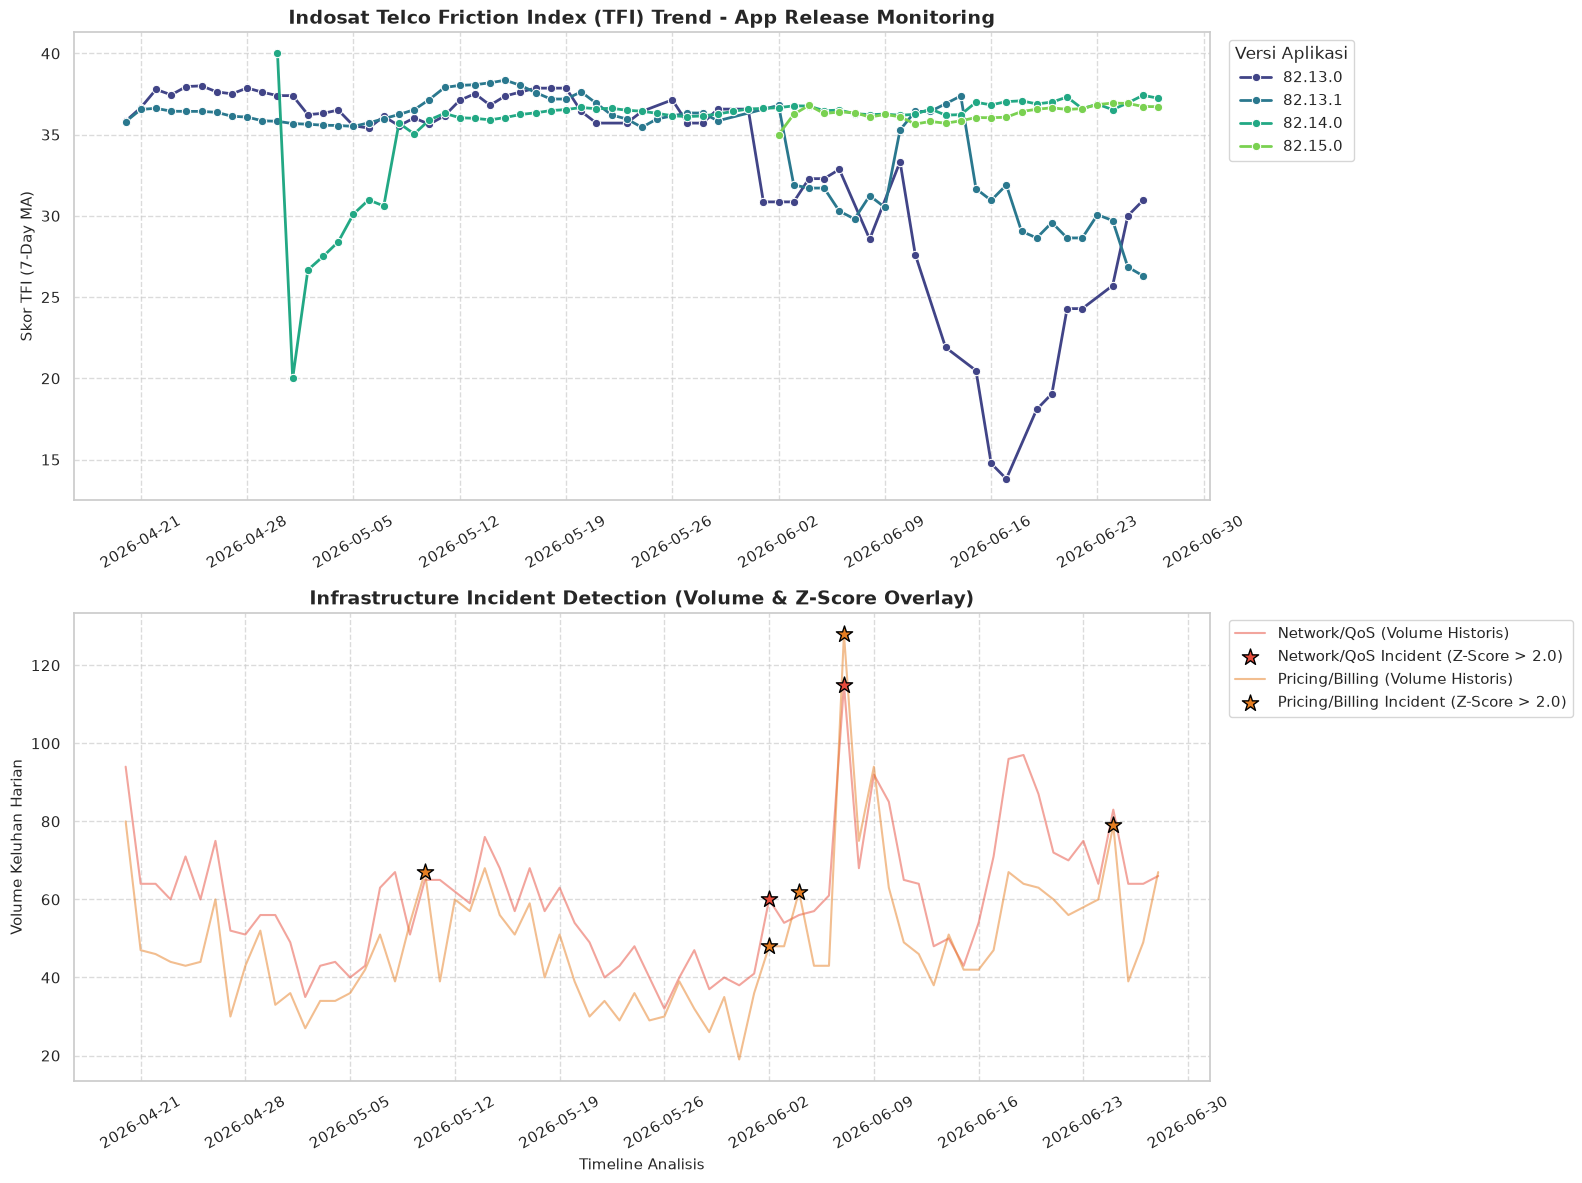

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def generate_portfolio_dashboard():
    print("[*] Merender dashboard visualisasi portofolio Indosat...")
    
    # Konfigurasi dasar kanvas (2 baris, 1 kolom)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # =======================================================
    # PANEL 1: TFI TREND (Deteksi Kegagalan Rilis Aplikasi)
    # =======================================================
    df_tfi = pd.read_csv("dataset_indosat/im3_tfi_multidimensional.csv", parse_dates=['date'])
    # Mitigasi bias hari parsial
    df_tfi = df_tfi[df_tfi['date'] != df_tfi['date'].max()].copy()
    
    # Isolasi versi riil dan ambil top 4 berdasarkan volume
    real_versions = df_tfi[df_tfi['reviewCreatedVersion'] != 'Unknown_Version']
    top_versions = real_versions.groupby('reviewCreatedVersion')['total_complaints'].sum().nlargest(4).index
    df_plot_tfi = df_tfi[df_tfi['reviewCreatedVersion'].isin(top_versions)]
    
    sns.lineplot(
        data=df_plot_tfi, x='date', y='TFI_MA_7D', hue='reviewCreatedVersion', 
        marker='o', linewidth=2, ax=axes[0], palette="viridis"
    )
    
    axes[0].set_title('Indosat Telco Friction Index (TFI) Trend - App Release Monitoring', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Skor TFI (7-Day MA)', fontsize=11)
    axes[0].set_xlabel('')
    axes[0].legend(title='Versi Aplikasi', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # =======================================================
    # PANEL 2: Z-SCORE (Deteksi Insiden Infrastruktur Masif)
    # =======================================================
    df_tagged = pd.read_csv("dataset_indosat/myim3_reviews_tagged.csv", parse_dates=['at'])
    df_tagged['date'] = df_tagged['at'].dt.date
    df_exploded = df_tagged.assign(complaint_category=df_tagged['complaint_category'].str.split(', ')).explode('complaint_category')
    
    daily_vol = df_exploded.groupby(['date', 'complaint_category']).size().reset_index(name='volume')
    pivot_vol = daily_vol.pivot(index='date', columns='complaint_category', values='volume').fillna(0)
    pivot_vol.index = pd.to_datetime(pivot_vol.index)
    
    targets = ['Network/QoS', 'Pricing/Billing']
    colors = {'Network/QoS': '#e74c3c', 'Pricing/Billing': '#e67e22'} # Merah dan Oranye
    
    for target in targets:
        if target in pivot_vol.columns:
            # Plot volume harian sebagai baseline
            axes[1].plot(pivot_vol.index, pivot_vol[target], label=f'{target} (Volume Historis)', color=colors[target], alpha=0.5, linewidth=1.5)
            
            # Kalkulasi Z-Score 14-Hari untuk menemukan anomali
            window_size = 14
            mean = pivot_vol[target].rolling(window=window_size, min_periods=1).mean()
            std = pivot_vol[target].rolling(window=window_size, min_periods=1).std().replace(0, np.nan)
            z_score = ((pivot_vol[target] - mean) / std).fillna(0)
            
            # Plot titik puncak (anomali)
            anomalies = pivot_vol[z_score > 2.0]
            if not anomalies.empty:
                axes[1].scatter(
                    anomalies.index, anomalies[target], 
                    color=colors[target], edgecolor='black', s=150, zorder=5, marker='*', 
                    label=f'{target} Incident (Z-Score > 2.0)'
                )

    axes[1].set_title('Infrastructure Incident Detection (Volume & Z-Score Overlay)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Volume Keluhan Harian', fontsize=11)
    axes[1].set_xlabel('Timeline Analisis', fontsize=11)
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # Format sumbu X agar tanggal mudah dibaca dan simetris antar-panel
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    output_path = 'dataset_indosat/indosat_portfolio_dashboard.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[SUCCESS] Dashboard visualisasi dirender secara penuh dan diamankan di: {output_path}")

# Trigger fungsi
generate_portfolio_dashboard()